# EnergiAI – Inteligencia para el Consumo Energético
### Hackathon ONE – Proyectos G9 | Team 72

## 1. Análisis Exploratorio de Datos (EDA) y Limpieza
- Carga del dataset sintético/público.
- Tratamiento de variables (consumo_kwh, uso_horario_pico, cantidad_equipos, tipo_inmueble, horas_alto_consumo).

## 2. Entrenamiento del Modelo Predictivo
- Criterios de clasificación (Eficiente, Moderado, Ineficiente).
- Modelos a evaluar: Random Forest / Árboles de Decisión / Regresión Logística.

## 3. Serialización del Modelo
- Exportación final a formato `.pkl` o `.joblib` para el equipo de Backend.

## 1. Análisis Exploratorio de Datos (EDA) y Limpieza

Por Zuleyca Guadalupe Balles Soto

Este notebook trabaja sobre el dataset simple (`data_simple_Team_72_EnergiAI`), la versión oficial acordada para el MVP: distribución ~75/25 vivienda/comercio, sin subcategorías de comercio, alineada a los 5 campos del contrato del API. El objetivo es (1) perfilar cada variable, (2) verificar calidad e integridad, (3) caracterizar el consumo y el perfil de eficiencia, y (4) dejar el dataset conformado y listo para modelado.

In [1]:
from google.colab import files
import zipfile, os

# 1. Se abre un botón para subir archivos
subido = files.upload()   # elige aquí data_simple_Team_72_EnergiAI.zip

# 2. Descomprime el zip subido
for nombre in subido:
    if nombre.endswith(".zip"):
        with zipfile.ZipFile(nombre) as z:
            z.extractall(".")
        print("Descomprimido:", nombre)

# 3. Verifica que quedó la carpeta
print(os.listdir("data_simple_Team_72_EnergiAI"))

Saving data_simple_Team_72_EnergiAI.zip to data_simple_Team_72_EnergiAI.zip
Descomprimido: data_simple_Team_72_EnergiAI.zip
['consumo_mensual.csv', 'establecimientos.csv', 'dataset_int_simple_team_72.py', 'dataset_simple_team_72.csv', 'curva_carga_horaria.csv', 'Matriz_Logica__Simple_EnergiAI_Teams_72.xlsx', 'umbrales_nuevos_team_72.py', 'data_simple_Team_72.py', 'Benchmark__Simple_EnergiAI_Teams_72.xlsx', 'inventario_equipos.csv', 'Diccionario_datos_Simple_EnergiAI_Teams_72.xlsx']


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta consistente para el perfil de eficiencia
PERF_COLORS = {"Eficiente": "#2e8b57", "Moderado": "#e0a800", "Ineficiente": "#c0392b"}
PERF_ORDER = ["Eficiente", "Moderado", "Ineficiente"]
print("Librerias cargadas.")

Librerias cargadas.


### 1. Carga de datos

In [3]:
# Resolucion robusta de la ruta de datos
CANDIDATES = ["data_simple_Team_72_EnergiAI", "data/data_simple_Team_72_EnergiAI", ".", "data"]
DATA_DIR = next((c for c in CANDIDATES if os.path.exists(os.path.join(c, "dataset_simple_team_72.csv"))), None)
assert DATA_DIR is not None, "No encuentro los CSV. Coloca la carpeta data_simple_Team_72_EnergiAI junto al notebook."
print("Usando DATA_DIR =", os.path.abspath(DATA_DIR))

est = pd.read_csv(os.path.join(DATA_DIR, "establecimientos.csv"))
eq  = pd.read_csv(os.path.join(DATA_DIR, "inventario_equipos.csv"))
con = pd.read_csv(os.path.join(DATA_DIR, "consumo_mensual.csv"))
cur = pd.read_csv(os.path.join(DATA_DIR, "curva_carga_horaria.csv"))
ds  = pd.read_csv(os.path.join(DATA_DIR, "dataset_simple_team_72.csv"))

tablas = {"establecimientos": est, "inventario_equipos": eq,
          "consumo_mensual": con, "curva_carga_horaria": cur, "dataset (consolidado)": ds}
for n, df in tablas.items():
    print(f"{n:26s} {df.shape[0]:>6,} filas x {df.shape[1]:>2} columnas")

Usando DATA_DIR = /content/data_simple_Team_72_EnergiAI
establecimientos            5,000 filas x  5 columnas
inventario_equipos         15,482 filas x  8 columnas
consumo_mensual             5,000 filas x  8 columnas
curva_carga_horaria        20,000 filas x  4 columnas
dataset (consolidado)       5,000 filas x 23 columnas


### 2. Perfilado de variables

Para cada tabla revisamos tipo de dato, valores nulos, cardinalidad y estadísticos básicos.

In [4]:
def perfilar(df, nombre):
    print("="*70)
    print(f"TABLA: {nombre}   ({df.shape[0]:,} filas x {df.shape[1]} columnas)")
    print("="*70)
    resumen = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "%_nulos": (df.isna().mean()*100).round(2),
        "unicos": df.nunique(),
        "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    return resumen

perfilar(est, "establecimientos")

TABLA: establecimientos   (5,000 filas x 5 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_inmueble,object,0,0.0,5000,VIV-00001
tipo_establecimiento,object,0,0.0,2,Vivienda
superficie_m2,int64,0,0.0,171,97
habitantes_empleados,int64,0,0.0,12,6
pais_ubicacion,object,0,0.0,6,Peru


In [5]:
perfilar(eq, "inventario_equipos")

TABLA: inventario_equipos   (15,482 filas x 8 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_equipo,object,0,0.0,15482,EQ-00001
id_inmueble,object,0,0.0,5000,VIV-00001
tipo_equipo,object,0,0.0,5,Iluminacion
cantidad_equipos,int64,0,0.0,60,15
potencia_watts,int64,0,0.0,7,15
tecnologia_inverter,bool,0,0.0,2,True
horas_uso_estimadas_dia,float64,0,0.0,603,10.95
consumo_kwh_dia_equipo,float64,0,0.0,3971,2.4638


In [6]:
perfilar(con, "consumo_mensual")

TABLA: consumo_mensual   (5,000 filas x 8 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_registro,object,0,0.0,5000,REG-00001
id_inmueble,object,0,0.0,5000,VIV-00001
anio_mes_dd,object,0,0.0,1,2026-07-01
consumo_kwh_mes,float64,0,0.0,4438,379.91
costo_factura_usd,float64,0,0.0,4344,284.93
costo_factura_moneda_local,float64,0,0.0,4883,1068.49
codigo_moneda,object,0,0.0,6,PEN
perfil_calculado,object,0,0.0,3,Ineficiente


In [7]:
perfilar(cur, "curva_carga_horaria")

TABLA: curva_carga_horaria   (20,000 filas x 4 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_curva,object,0,0.0,20000,C-00001
id_inmueble,object,0,0.0,5000,VIV-00001
franja_horaria,object,0,0.0,4,Madrugada
porcentaje_distribucion,float64,0,0.0,4390,0.0965


In [8]:
perfilar(ds, "dataset_simple_team_72 (consolidado)")

TABLA: dataset_simple_team_72 (consolidado)   (5,000 filas x 23 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_registro,object,0,0.0,5000,REG-00001
id_inmueble,object,0,0.0,5000,VIV-00001
anio_mes_dd,object,0,0.0,1,2026-07-01
pais_ubicacion,object,0,0.0,6,Peru
tipo_establecimiento,object,0,0.0,2,Vivienda
superficie_m2,int64,0,0.0,171,97
habitantes_empleados,int64,0,0.0,12,6
total_equipos,float64,0,0.0,65,17.0
potencia_total_watts,float64,0,0.0,577,1775.0
tiene_inverter,float64,0,0.0,1,1.0


In [9]:
# Estadisticos descriptivos de las variables numericas clave
num_cols = ["superficie_m2","habitantes_empleados","total_equipos","potencia_total_watts",
            "porcentaje_inverter","consumo_kwh_dia","consumo_kwh_mes",
            "intensidad_energetica_kwh_m2","costo_factura_usd"]
ds[[c for c in num_cols if c in ds.columns]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
superficie_m2,5000.0,96.22,35.07,30.00,72.00,93.00,115.00,200.00
habitantes_empleados,5000.0,4.42,2.68,1.00,2.00,4.00,6.00,12.00
total_equipos,5000.0,29.14,14.48,12.00,19.00,26.00,32.00,76.00
potencia_total_watts,5000.0,2985.68,2303.06,1530.00,1715.00,1820.00,3310.00,10650.00
porcentaje_inverter,5000.0,0.57,0.21,0.33,0.33,0.67,0.67,1.00
consumo_kwh_dia,5000.0,24.50,25.79,7.02,9.24,12.40,28.90,117.56
consumo_kwh_mes,5000.0,735.00,773.67,210.65,277.06,372.14,867.05,3526.65
intensidad_energetica_kwh_m2,5000.0,8.57,11.22,1.40,3.13,4.25,7.95,114.04
costo_factura_usd,5000.0,551.25,580.26,157.99,207.80,279.10,650.28,2644.99


### 3. Calidad e integridad de la data

Verificamos nulos, llaves, integridad referencial y cardinalidad entre tablas.

In [10]:
checks = []
for n, df in tablas.items():
    checks.append((f"Nulos en {n}", int(df.isna().sum().sum()), 0))
valid = set(est.id_inmueble)
for n, df in [("inventario_equipos",eq),("consumo_mensual",con),("curva_carga_horaria",cur),("dataset",ds)]:
    checks.append((f"FK huerfanas en {n}", len(set(df.id_inmueble)-valid), 0))
checks.append(("Inmuebles sin equipos", len(valid-set(eq.id_inmueble)), 0))
checks.append(("Inmuebles con != 4 franjas", int((cur.groupby('id_inmueble').size()!=4).sum()), 0))
checks.append(("Inmuebles con != 1 consumo", int((con.groupby('id_inmueble').size()!=1).sum()), 0))

res = pd.DataFrame(checks, columns=["verificacion","valor","esperado"])
res["estado"] = np.where(res.valor==res.esperado, "OK", "REVISAR")
res

,verificacion,valor,esperado,estado
0,Nulos en establecimientos,0,0,OK
1,Nulos en inventario_equipos,0,0,OK
2,Nulos en consumo_mensual,0,0,OK
3,Nulos en curva_carga_horaria,0,0,OK
4,Nulos en dataset (consolidado),0,0,OK
5,FK huerfanas en inventario_equipos,0,0,OK
6,FK huerfanas en consumo_mensual,0,0,OK
7,FK huerfanas en curva_carga_horaria,0,0,OK
8,FK huerfanas en dataset,0,0,OK
9,Inmuebles sin equipos,0,0,OK


### 4. Análisis univariado — Establecimientos

Composición de la cartera: tipo de inmueble, país y variables físicas. En el dataset simple no hay subcategorías de comercio; el inmueble es solo Vivienda o Comercio.

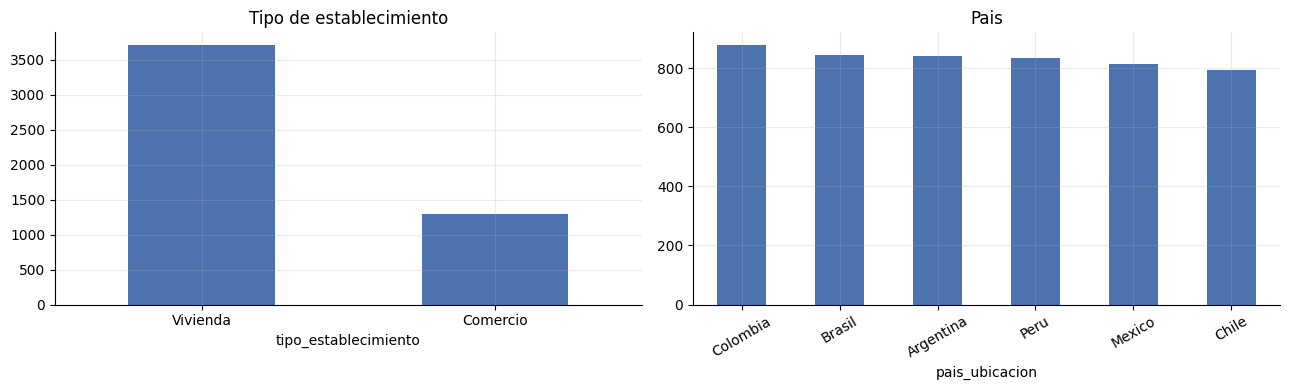

Proporcion Vivienda vs Comercio:
tipo_establecimiento
Vivienda    74.2
Comercio    25.8


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
est.tipo_establecimiento.value_counts().plot.bar(ax=axes[0], color="#4c72b0")
axes[0].set_title("Tipo de establecimiento"); axes[0].tick_params(axis='x', rotation=0)
est.pais_ubicacion.value_counts().plot.bar(ax=axes[1], color="#4c72b0")
axes[1].set_title("Pais"); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print("Proporcion Vivienda vs Comercio:")
print((est.tipo_establecimiento.value_counts(normalize=True)*100).round(1).to_string())

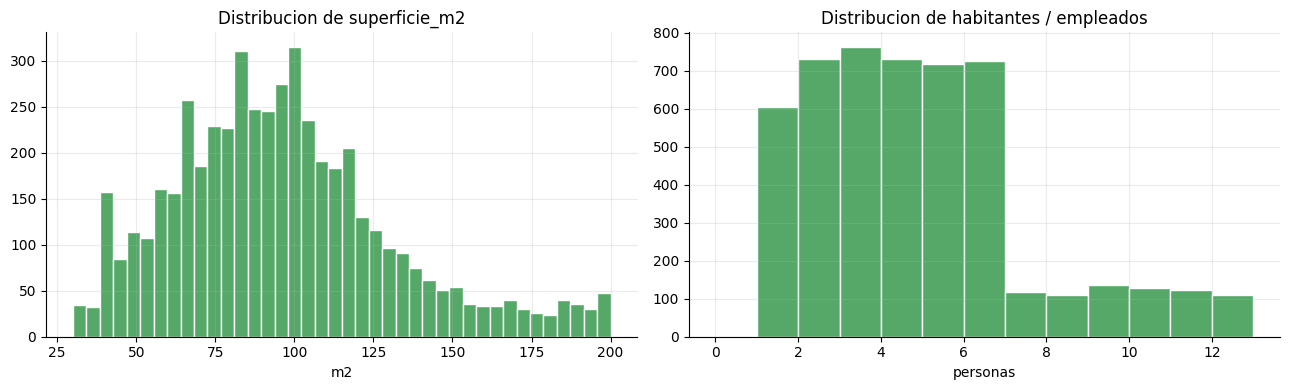

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(est.superficie_m2, bins=40, color="#55a868", edgecolor="white")
axes[0].set_title("Distribucion de superficie_m2"); axes[0].set_xlabel("m2")
axes[1].hist(est.habitantes_empleados, bins=range(0,14), color="#55a868", edgecolor="white")
axes[1].set_title("Distribucion de habitantes / empleados"); axes[1].set_xlabel("personas")
plt.tight_layout(); plt.show()

### 5. Análisis univariado — Inventario de equipos

Mezcla de equipos, potencia declarada y penetración de tecnología Inverter.

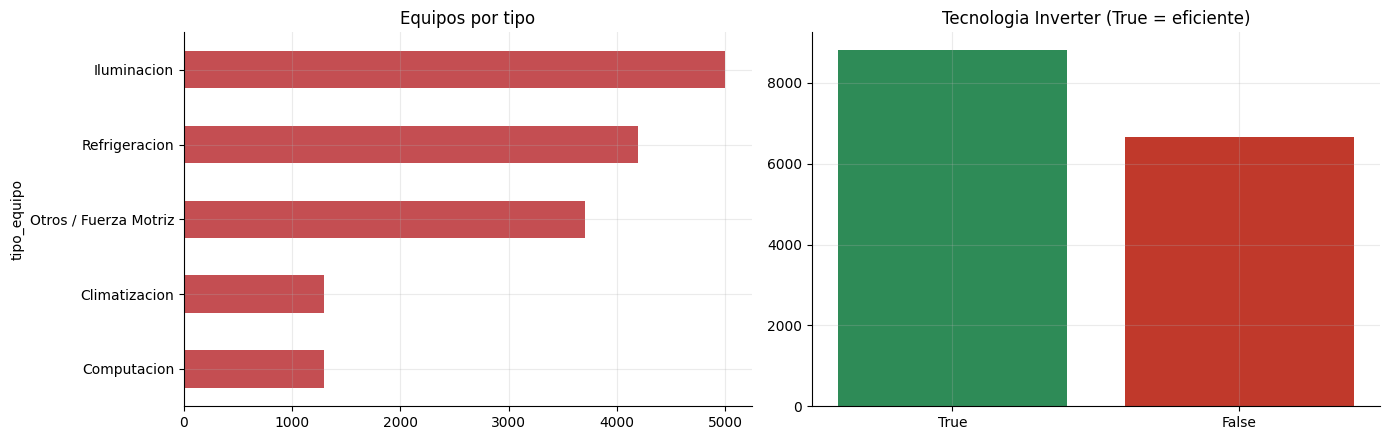

Penetracion Inverter global: 56.9% de los equipos


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
eq.tipo_equipo.value_counts().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Equipos por tipo"); axes[0].invert_yaxis()
inv = eq.tecnologia_inverter.value_counts()
axes[1].bar(inv.index.astype(str), inv.values, color=["#2e8b57","#c0392b"])
axes[1].set_title("Tecnologia Inverter (True = eficiente)")
plt.tight_layout(); plt.show()
print("Penetracion Inverter global: {:.1f}% de los equipos".format(eq.tecnologia_inverter.mean()*100))

In [14]:
tab = eq.groupby("tipo_equipo").agg(
    potencia_mediana_w=("potencia_watts","median"),
    horas_uso_mediana=("horas_uso_estimadas_dia","median"),
    kwh_dia_medio=("consumo_kwh_dia_equipo","mean"),
    n=("id_equipo","size")).round(2).sort_values("kwh_dia_medio", ascending=False)
tab

,potencia_mediana_w,horas_uso_mediana,kwh_dia_medio,n
tipo_equipo,,,,
Climatizacion,2200.0,9.00,39.68,1290
Refrigeracion,350.0,24.00,8.75,4192
Computacion,150.0,8.00,8.52,1290
Iluminacion,15.0,9.01,3.39,5000
Otros / Fuerza Motriz,1200.0,1.50,1.80,3710


### 6. Consumo, costo y perfil de eficiencia

Distribución del consumo mensual y de la intensidad energética de los comercios.

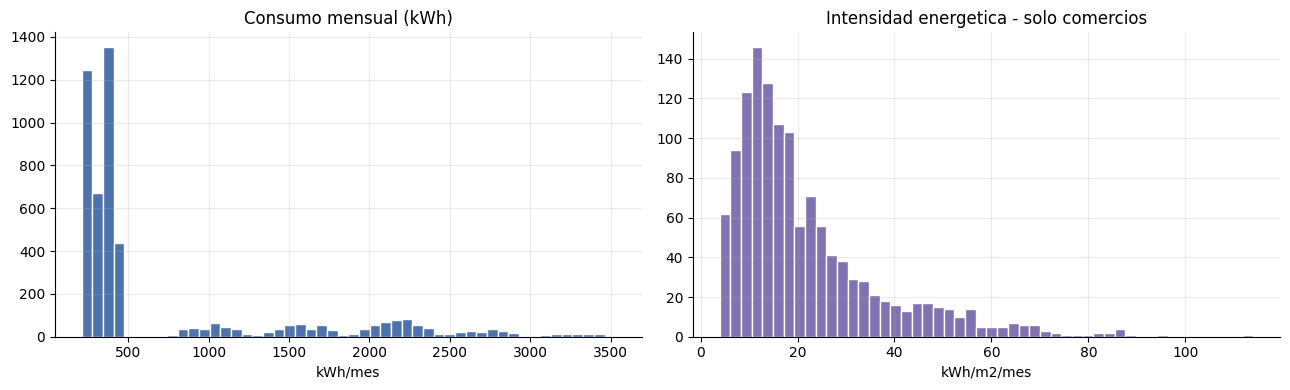

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ds.consumo_kwh_mes, bins=50, color="#4c72b0", edgecolor="white")
axes[0].set_title("Consumo mensual (kWh)"); axes[0].set_xlabel("kWh/mes")
com = ds[ds.tipo_establecimiento=="Comercio"]
axes[1].hist(com.intensidad_energetica_kwh_m2, bins=50, color="#8172b3", edgecolor="white")
axes[1].set_title("Intensidad energetica - solo comercios"); axes[1].set_xlabel("kWh/m2/mes")
plt.tight_layout(); plt.show()

### 7. Curva de carga horaria

Perfil promedio de consumo por franja. El dataset simple ya trae las franjas como columnas (pct_dist_*).

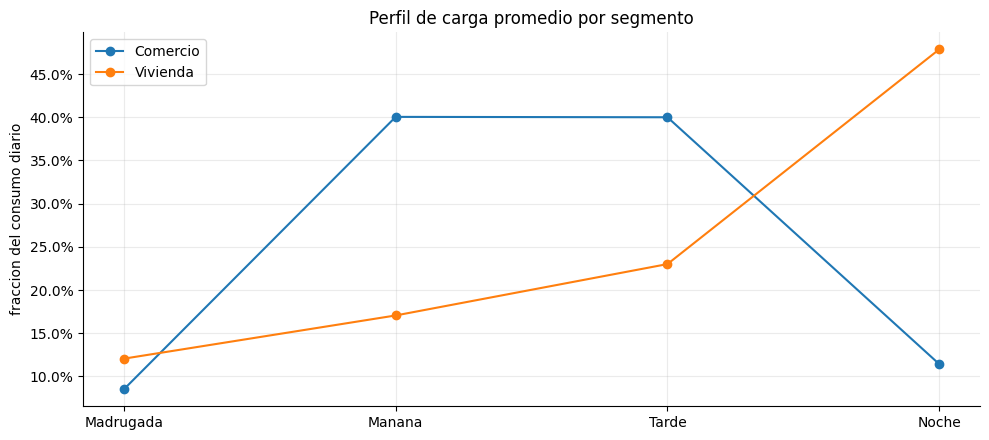

In [16]:
FR = {"pct_dist_madrugada":"Madrugada","pct_dist_manana":"Manana",
      "pct_dist_tarde":"Tarde","pct_dist_noche":"Noche"}
cols_fr = list(FR.keys())
seg = ds.tipo_establecimiento

fig, ax = plt.subplots(figsize=(10,4.5))
for s, g in ds.groupby("tipo_establecimiento"):
    ax.plot(list(FR.values()), g[cols_fr].mean().values, marker="o", label=s)
ax.set_title("Perfil de carga promedio por segmento")
ax.set_ylabel("fraccion del consumo diario")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
# Revision de porcentajes negativos en la curva
neg = ds[(ds[cols_fr] < 0).any(axis=1)]
print("Inmuebles con alguna franja negativa:", len(neg))
if len(neg):
    print("Se corrigen en la seccion 11 (piso positivo + renormalizacion).")
    display(neg[["id_inmueble","tipo_establecimiento"]+cols_fr].head())

Inmuebles con alguna franja negativa: 5
Se corrigen en la seccion 11 (piso positivo + renormalizacion).


,id_inmueble,tipo_establecimiento,pct_dist_madrugada,pct_dist_manana,pct_dist_tarde,pct_dist_noche
3230,COM-03231,Comercio,0.1184,0.4439,0.4394,-0.0016
3792,COM-03793,Comercio,0.1179,0.4393,0.4446,-0.0018
3827,COM-03828,Comercio,0.1198,0.4344,0.4473,-0.0015
4126,COM-04127,Comercio,0.1068,0.4498,0.4463,-0.0029
4136,COM-04137,Comercio,0.1187,0.4458,0.4379,-0.0024


**Hallazgo del análisis (calidad).** Se detectan 5 inmuebles con una franja de distribución en valor negativo, algo físicamente imposible (una franja no puede ser un porcentaje negativo del consumo diario). Es un residuo del generador de la curva. Se corrige en la sección 11 acotando cada franja a un piso positivo y renormalizando a 1.0. Impacto bajo (5 de 5000).

### 8. La variable objetivo (`efficiency_label`)

Distribución del target global y por segmento.

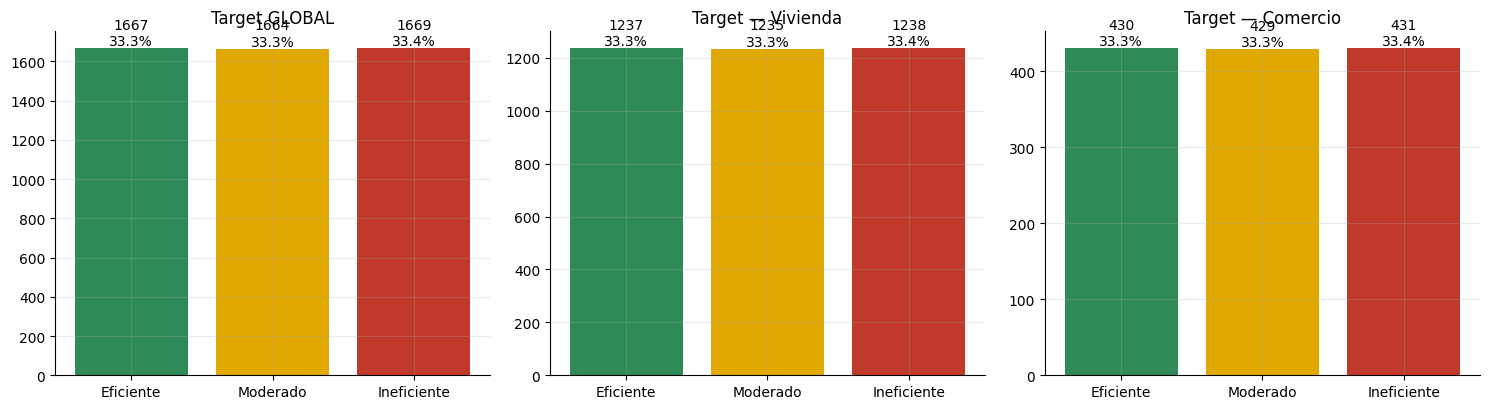

efficiency_label
Ineficiente    1669
Eficiente      1667
Moderado       1664


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
g = ds.efficiency_label.value_counts().reindex(PERF_ORDER)
axes[0].bar(PERF_ORDER, g.values, color=[PERF_COLORS[p] for p in PERF_ORDER])
axes[0].set_title("Target GLOBAL")
for i,v in enumerate(g.values): axes[0].text(i, v, f"{v}\n{v/len(ds)*100:.1f}%", ha="center", va="bottom")
for ax, seg_name in zip(axes[1:], ["Vivienda","Comercio"]):
    sub = ds[ds.tipo_establecimiento==seg_name].efficiency_label.value_counts().reindex(PERF_ORDER).fillna(0)
    ax.bar(PERF_ORDER, sub.values, color=[PERF_COLORS[p] for p in PERF_ORDER])
    ax.set_title(f"Target — {seg_name}"); tot=sub.sum()
    for i,v in enumerate(sub.values): ax.text(i, v, f"{int(v)}\n{v/tot*100:.1f}%", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(ds.efficiency_label.value_counts().to_string())

**Hallazgo del análisis (balance)**. El target viene balanceado a 33/33/33, y no solo a nivel global: también dentro de cada segmento (Vivienda y Comercio). Esto se debe a que los umbrales del dataset simple se definieron por terciles de cada segmento. Es una condición ideal para entrenamiento: ninguna clase queda infrarrepresentada, no hace falta rebalancear.

### 9. Relación entre consumo y etiqueta (data leakage)

El `efficiency_label` se calcula por umbral sobre `consumo_kwh_dia` (viviendas) e `intensidad_energetica` (comercios). Ambas magnitudes derivan de `consumo_kwh`, que es feature.

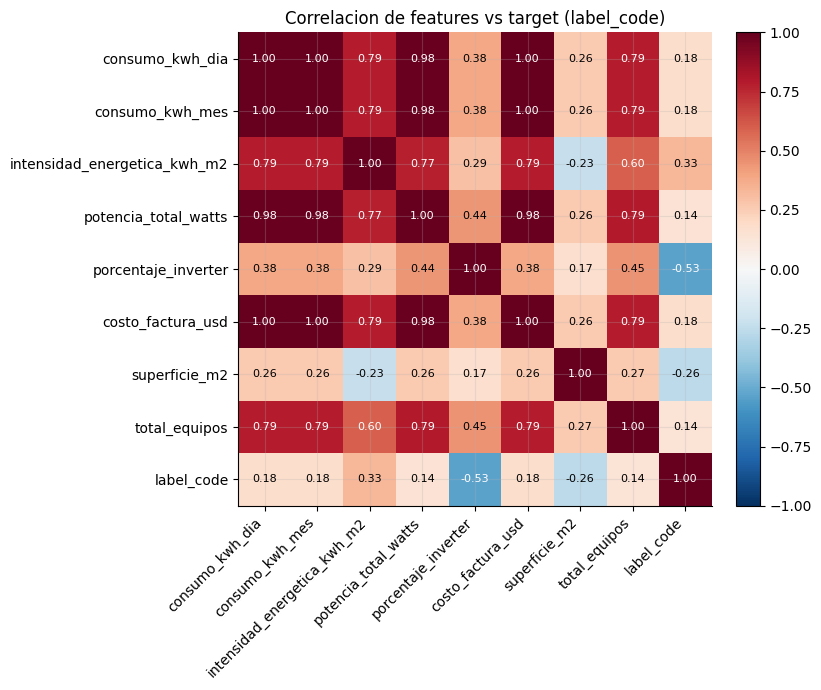

In [19]:
ds2 = ds.copy()
ds2["label_code"] = ds2.efficiency_label.map({"Eficiente":0,"Moderado":1,"Ineficiente":2})
corr_cols = [c for c in ["consumo_kwh_dia","consumo_kwh_mes","intensidad_energetica_kwh_m2",
             "potencia_total_watts","porcentaje_inverter","costo_factura_usd",
             "superficie_m2","total_equipos","label_code"] if c in ds2.columns]
corr = ds2[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8.5,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlacion de features vs target (label_code)")
plt.tight_layout(); plt.show()

In [20]:
# Una regla de umbral sobre una sola columna reproduce el label
viv = ds[ds.tipo_establecimiento=="Vivienda"]
q = viv.consumo_kwh_dia.quantile([1/3, 2/3]).values
lab = pd.cut(viv.consumo_kwh_dia, [-np.inf, q[0], q[1], np.inf],
             labels=["Eficiente","Moderado","Ineficiente"]).astype(str)
print(f"Regla de tercil sobre consumo_kwh_dia reproduce el label en viviendas: {(lab==viv.efficiency_label).mean()*100:.1f}%")

Regla de tercil sobre consumo_kwh_dia reproduce el label en viviendas: 99.9%


**Hallazgo del análisis (leakage).** El target es una función determinística por umbral de `consumo_kwh_dia` / `intensidad_energetica`, columnas que se derivan de `consumo_kwh` (una feature). Un modelo que incluya el consumo alcanzará una exactitud muy alta reproduciendo la regla, más que "aprendiendo" un patrón. Es inherente a la naturaleza sintética de la data (el consumo se generó por fórmula, sin la variabilidad real de hábitos, clima o aislamiento). Para el MVP es aceptable —el contrato del API entrega `consumo_kwh`—, pero conviene no sobreinterpretar el accuracy y reportarlo con esta salvedad.

### 10. Señal en variables independientes

Variables que no derivan del cálculo del target y sí podrían aportar señal propia: penetración Inverter, mezcla de equipos, país.

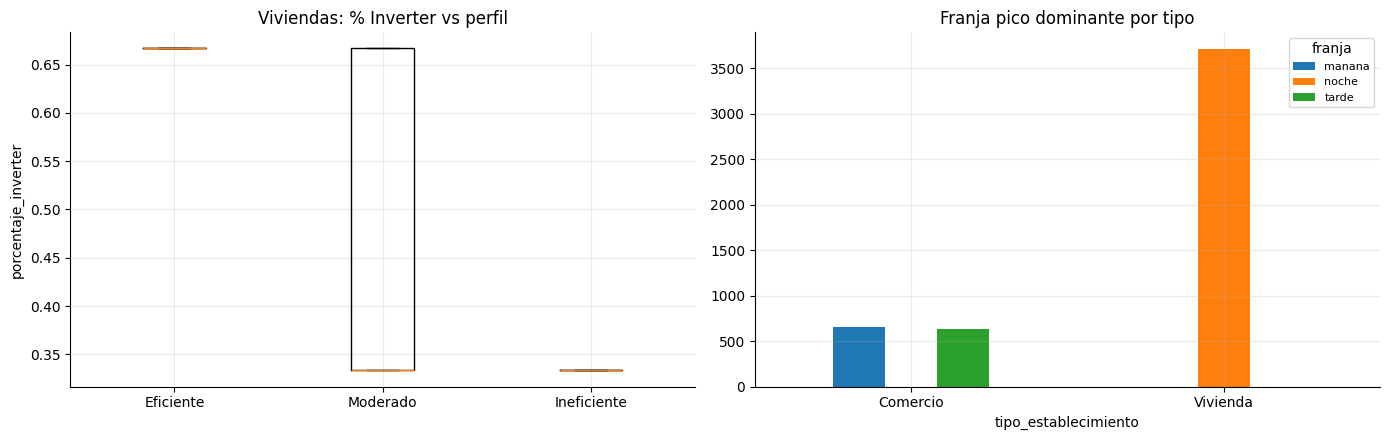

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
viv = ds[ds.tipo_establecimiento=="Vivienda"]
data_box = [viv[viv.efficiency_label==p].porcentaje_inverter.values for p in PERF_ORDER if (viv.efficiency_label==p).any()]
labels_box = [p for p in PERF_ORDER if (viv.efficiency_label==p).any()]
axes[0].boxplot(data_box)
axes[0].set_xticks(range(1, len(labels_box)+1)); axes[0].set_xticklabels(labels_box)
axes[0].set_title("Viviendas: % Inverter vs perfil"); axes[0].set_ylabel("porcentaje_inverter")
pico = ds.groupby(["tipo_establecimiento","franja_pico_dominante"]).size().unstack(fill_value=0)
pico.plot.bar(ax=axes[1]); axes[1].set_title("Franja pico dominante por tipo")
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(title="franja", fontsize=8)
plt.tight_layout(); plt.show()

### 11. Limpieza y tratamiento de variables

Conformamos el dataset al esquema del contrato del API (POST /`analisis-energetico`), corregimos las curvas negativas y derivamos las dos variables que el contrato pide y no existen directamente en las tablas.

**Esquema del contrato:** `consumo_kwh`, `uso_horario_pico`, `cantidad_equipos`, `tipo_inmueble`, `horas_alto_consumo` -> salida `categoria`.

#### 11.1 Corrección de las curvas de carga con porcentaje negativo

In [22]:
cols_fr = ["pct_dist_madrugada","pct_dist_manana","pct_dist_tarde","pct_dist_noche"]
FLOOR = 0.02
piv = ds.set_index("id_inmueble")[cols_fr].copy()
mask_neg = (piv < 0).any(axis=1)
print("Inmuebles con franja negativa (ANTES):", int(mask_neg.sum()))

sub = piv.loc[mask_neg].clip(lower=FLOOR)
piv.loc[mask_neg] = sub.div(sub.sum(axis=1), axis=0).round(4)
print("Inmuebles con franja negativa (DESPUES):", int((piv < 0).any(axis=1).sum()))
print("Sumas fuera de [0.98,1.02]:", int((piv.sum(axis=1).sub(1).abs()>0.02).sum()))

# devolver las franjas corregidas al dataset
for c in cols_fr:
    ds[c] = ds["id_inmueble"].map(piv[c])
# recomputar franja pico por si algun maximo cambio
ds["franja_pico_dominante"] = (ds[cols_fr].idxmax(axis=1)
                               .str.replace("pct_dist_","", regex=False))

Inmuebles con franja negativa (ANTES): 5
Inmuebles con franja negativa (DESPUES): 0
Sumas fuera de [0.98,1.02]: 0


#### 11.2 Derivación de las dos variables del contrato

* `uso_horario_pico` (bool): True si la franja de mayor consumo cae en la ventana pico (Tarde o Noche).

* `horas_alto_consumo` (int): horas del día con consumo por encima del reparto uniforme, leídas de la curva. Se cuentan las franjas por encima de 0.25 (uniforme) y se multiplican por 6 h (cada franja = 6 h del día). Es una medida directa de "horas del día con consumo alto", en rango 0–24.


In [23]:
# uso_horario_pico
ds["uso_horario_pico"] = ds["franja_pico_dominante"].isin(["tarde","noche"])

# horas_alto_consumo (franjas por encima del uniforme x 6h)
UNIFORME = 0.25
HORAS_FRANJA = 6
ds["horas_alto_consumo"] = ((ds[cols_fr] > UNIFORME).sum(axis=1) * HORAS_FRANJA).astype(int)

print("uso_horario_pico  -> True en {:.1f}% de los inmuebles".format(ds.uso_horario_pico.mean()*100))
print("horas_alto_consumo:")
print(ds.horas_alto_consumo.value_counts().sort_index().to_string())

uso_horario_pico  -> True en 87.0% de los inmuebles
horas_alto_consumo:
horas_alto_consumo
6     2594
12    2406


#### 11.3 Conformado al esquema del contrato y exportación

Mapeo: `consumo_kwh <- consumo_kwh_mes`, `cantidad_equipos <- total_equipos`, `tipo_inmueble` con Vivienda -> "Casa". Se conserva `consumo_kwh` (campo obligatorio del contrato) y se incluye `superficie_m2` para el cálculo de eficiencia de comercios.

In [24]:
MAP_TIPO = {"Vivienda":"Casa","Comercio":"Comercio"}
model_df = pd.DataFrame({
    "id_inmueble":        ds.id_inmueble,
    "consumo_kwh":        ds.consumo_kwh_mes.round(2),
    "uso_horario_pico":   ds.uso_horario_pico.astype(bool),
    "cantidad_equipos":   ds.total_equipos.astype(int),
    "tipo_inmueble":      ds.tipo_establecimiento.map(MAP_TIPO),
    "horas_alto_consumo": ds.horas_alto_consumo.astype(int),
    "superficie_m2":      ds.superficie_m2.round(2),
    "categoria":          ds.efficiency_label,
})

print("Shape:", model_df.shape)
print("Nulos:", int(model_df.isna().sum().sum()))
print("tipo_inmueble:", dict(model_df.tipo_inmueble.value_counts()))
print("categoria    :", dict(model_df.categoria.value_counts()))

model_df.to_csv("consumo_energia_sintetico.csv", index=False)
print("\nGuardado: consumo_energia_sintetico.csv")
model_df.head()

Shape: (5000, 8)
Nulos: 0
tipo_inmueble: {'Casa': np.int64(3710), 'Comercio': np.int64(1290)}
categoria    : {'Ineficiente': np.int64(1669), 'Eficiente': np.int64(1667), 'Moderado': np.int64(1664)}

Guardado: consumo_energia_sintetico.csv


,id_inmueble,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,superficie_m2,categoria
0,VIV-00001,379.91,True,17,Casa,12,97,Ineficiente
1,COM-00002,3369.01,True,44,Comercio,12,169,Moderado
2,VIV-00003,375.82,True,20,Casa,6,73,Ineficiente
3,VIV-00004,373.16,True,15,Casa,6,40,Ineficiente
4,COM-00005,846.67,True,31,Comercio,12,117,Eficiente


### 12. Conclusiones y estado para la fase de modelado

**Calidad de la data.** El dataset simple es sólido: sin nulos, sin llaves duplicadas ni referencias huérfanas; costos e intensidad energética recalculan de forma exacta. El target viene balanceado 33/33/33 por segmento, sin subcategorías de comercio, alineado a los 5 campos del contrato del API.

**Hallazgos del análisis:**

1. **Balance** — target 33/33/33 por terciles, ideal para clasificación.

2. **Calidad** — 5 curvas con franja negativa (corregidas en la sección 11).

3. **Leakage** — el target es determinístico a partir de `consumo_kwh`; el accuracy será alto por diseño de la data sintética. Aceptable para el MVP; se reporta con la salvedad.

**Entregable de limpieza.** Se generó `consumo_energia_sintetico.csv`, conformado al esquema del contrato, con las curvas corregidas y las dos variables (`uso_horario_pico`, `horas_alto_consumo`) ya derivadas. El dataset queda listo para entrenamiento.